In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
ti = sns.load_dataset("titanic")

In [4]:
ti.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
ti.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
features = ["pclass", "sex", "age", "fare","embarked" ]
target = ["survived"]

In [7]:
from sklearn.impute import SimpleImputer
mean_val = SimpleImputer(strategy="median")
ti[["age"]] = mean_val.fit_transform(ti[["age"]])
frequent_val = SimpleImputer(strategy="most_frequent")
ti[["embarked"]] = frequent_val.fit_transform(ti[["embarked"]])

In [8]:
ti.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
#encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ti["sex"] = le.fit_transform(ti["sex"])
ti["embarked"] = le.fit_transform(ti["embarked"])

In [10]:
ti.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,1,27.0,0,0,13.00,2,Second,man,True,NaN,Southampton,no,True
887,1,1,0,19.0,0,0,30.00,2,First,woman,False,B,Southampton,yes,True
888,0,3,0,28.0,1,2,23.45,2,Third,woman,False,NaN,Southampton,no,False
889,1,1,1,26.0,0,0,30.00,0,First,man,True,C,Cherbourg,yes,True
890,0,3,1,32.0,0,0,7.75,1,Third,man,True,NaN,Queenstown,no,True


In [11]:
X = ti[features]
y = ti[target]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#Desicion tree

In [14]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

model.fit(X_train, y_train)
y_pre = model.predict(X_test)

In [15]:
y_pre

array([0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

In [16]:
from sklearn.metrics import accuracy_score
print("accuracy_score : ", accuracy_score( y_test, y_pre) )

accuracy_score :  0.770949720670391


[Text(0.5, 0.875, 'sex <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]\nclass = Died'),
 Text(0.25, 0.625, 'pclass <= 2.5\ngini = 0.386\nsamples = 245\nvalue = [64, 181]\nclass = survived'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'age <= 2.5\ngini = 0.074\nsamples = 130\nvalue = [5, 125]\nclass = survived'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'fare <= 23.35\ngini = 0.5\nsamples = 115\nvalue = [59.0, 56.0]\nclass = Died'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'age <= 6.5\ngini = 0.303\nsamples = 467\nvalue = [380, 87]\nclass = Died'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'pclass <= 2.5\ngini = 0.434\nsamples = 22\nvalue = [7.0, 15.0]\nclass = survived'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'pclass <= 1.5\ngini = 0.271\nsamples = 445\nvalue = [373, 72]\nclass = Died'),
 Tex

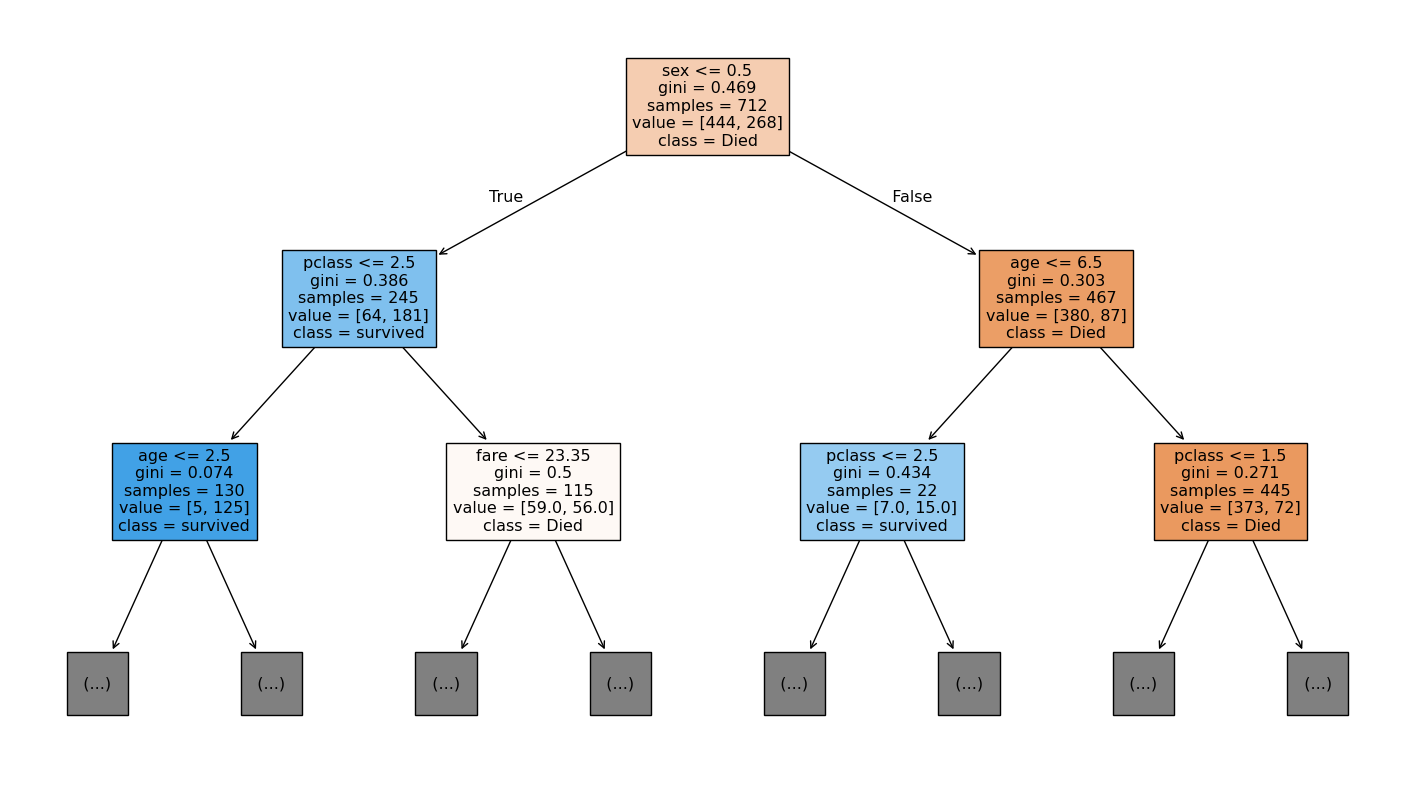

In [17]:
from sklearn.tree  import plot_tree
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "survived"],
    filled=True,
    max_depth=2
    
)

# pre-pouning = is not used more so we do post-puning

# post purning 

In [21]:
full_tree =  DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alpha = path.ccp_alphas

In [26]:
ccp_alpha

array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
       1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
       3.51123596e-04, 4.68164794e-04, 4.68164794e-04, 5.61797753e-04,
       6.24219725e-04, 6.67991230e-04, 7.02247191e-04, 7.02247191e-04,
       8.19288390e-04, 8.19288390e-04, 8.32292967e-04, 8.42696629e-04,
       8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
       9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
       9.88347898e-04, 1.00253471e-03, 1.05337079e-03, 1.07400895e-03,
       1.08038029e-03, 1.11865144e-03, 1.12359551e-03, 1.12359551e-03,
       1.13139825e-03, 1.17041199e-03, 1.18841832e-03, 1.22566125e-03,
       1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
       1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
       1.46301498e-03, 1.47927070e-03, 1.51142557e-03, 1.54072312e-03,
       1.56675436e-03, 1.60434338e-03, 1.66892062e-03, 1.76144762e-03,
      

In [28]:
from sklearn.model_selection import cross_val_score

cv_scores = []

for alpha in ccp_alpha:

    tree = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )

    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())

In [31]:
best_index = cv_scores.index(max(cv_scores))

best_alpha = ccp_alphas[best_index]

print("Best Alpha:", best_alpha)
print("Best CV Score:", cv_scores[best_index])

Best Alpha: 0.001761447615767647
Best CV Score: 0.8146656160740668


In [34]:
cv_scores

[np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7781443908204472),
 np.float64(0.7725204373091696),
 np.float64(0.7725204373091696),
 np.float64(0.7739288880133952),
 np.float64(0.7739288880133952),
 np.float64(0.7739288880133952),
 np.float64(0.7739288880133952),
 np.float64(0.7739288880133952),
 np.float64(0.7739288880133952),
 np.float64(0.7739288880133952),
 np.float64(0.7739288880133952),
 np.float64(0.7739288880133952),
 np.float64(0.7739288880133952),
 np.float64(0.7711119866049445),
 np.float64(0.7739288880133951),
 np.float64(0.7739288880133951),
 np.float64(0.7739288880133951),
 np.float64(0.7767457894218458),
 np.float64(0.7767457894218458),
 np.float6

In [36]:
full_tree =  DecisionTreeClassifier(ccp_alpha=best_alpha)
full_tree.fit(X_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.42045454545454547, 0.95, 'sex <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]\nclass = Died'),
 Text(0.22727272727272727, 0.85, 'pclass <= 2.5\ngini = 0.386\nsamples = 245\nvalue = [64, 181]\nclass = survived'),
 Text(0.32386363636363635, 0.8999999999999999, 'True  '),
 Text(0.18181818181818182, 0.75, 'gini = 0.074\nsamples = 130\nvalue = [5, 125]\nclass = survived'),
 Text(0.2727272727272727, 0.75, 'fare <= 23.35\ngini = 0.5\nsamples = 115\nvalue = [59.0, 56.0]\nclass = Died'),
 Text(0.22727272727272727, 0.65, 'embarked <= 1.5\ngini = 0.486\nsamples = 94\nvalue = [39, 55]\nclass = survived'),
 Text(0.13636363636363635, 0.55, 'fare <= 15.373\ngini = 0.405\nsamples = 39\nvalue = [11, 28]\nclass = survived'),
 Text(0.09090909090909091, 0.45, 'fare <= 13.935\ngini = 0.471\nsamples = 29\nvalue = [11, 18]\nclass = survived'),
 Text(0.045454545454545456, 0.35, 'gini = 0.386\nsamples = 23\nvalue = [6, 17]\nclass = survived'),
 Text(0.13636363636363635, 0.35, 'age <= 28.5\ngini

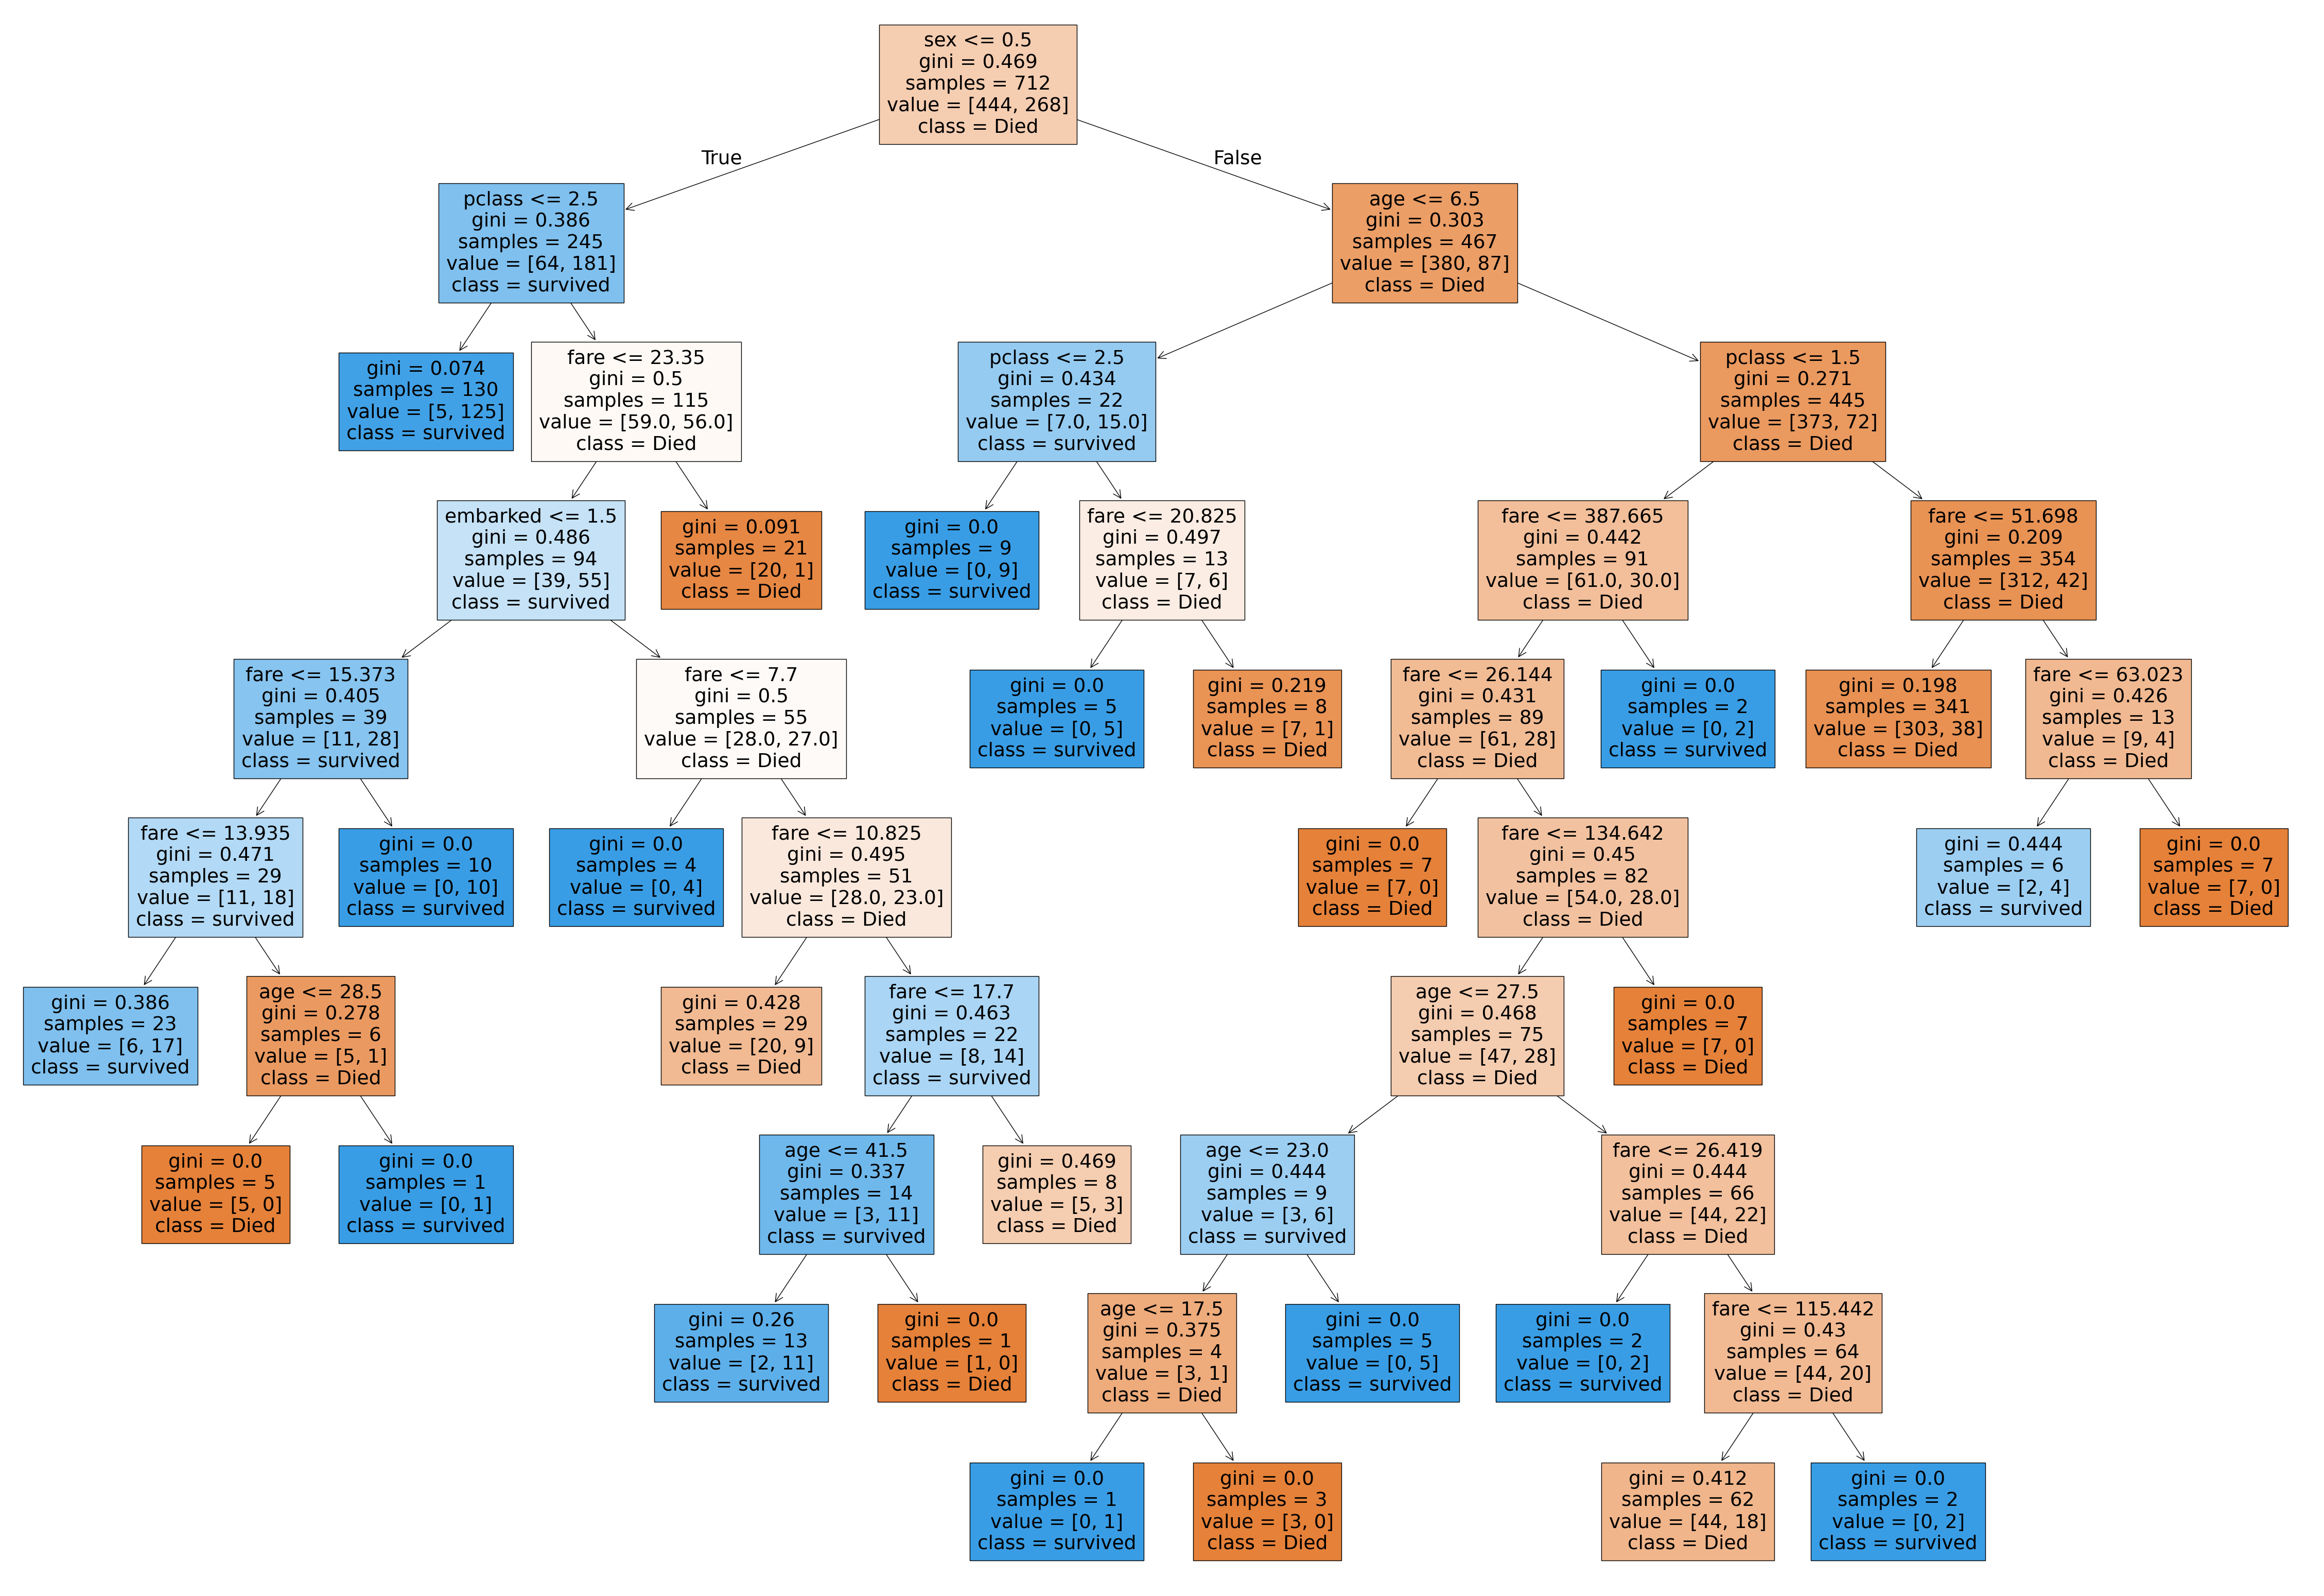

In [44]:
from sklearn.tree  import plot_tree
plt.figure(figsize=(58, 40))
plot_tree(
    full_tree,
    feature_names=X.columns,
    class_names=["Died", "survived"],
    filled=True,
    
)

In [40]:
print(full_tree.score(X_test, y_test))

0.8324022346368715
